# Null-Swap Protocol: Random Forest Logloss Direct Implementation

This notebook implements the **null-swap protocol** using **Random Forest logloss directly**, without converting to mutual information.

## Objective

Validate that the swap criterion $\widetilde{\Delta}_S = \text{LogLoss}(Y, \mathbf{X}_S^{\mathrm{null}}) - \text{LogLoss}(Y, \mathbf{X}_S)$ correctly identifies:
- **Informative combinations** ($S \in \mathcal{I}$): $\widetilde{\Delta}_S > 0$ (original logloss < null logloss)
- **Non-informative combinations** ($S \notin \mathcal{I}$): $\widetilde{\Delta}_S \approx 0$ (original logloss ≈ null logloss)

## Key Approach

We use **Random Forest logloss** directly as the protocol metric:
- Lower logloss = better predictions = more information in $X_S$ about $Y$
- If $\text{LogLoss}(Y, X_S) < \text{LogLoss}(Y, X_S^{\text{null}})$ → $X_S$ contains information
- If $\text{LogLoss}(Y, X_S) \approx \text{LogLoss}(Y, X_S^{\text{null}})$ → $X_S$ contains no information

## XOR as Test Case

The XOR pattern is ideal because it exhibits **contextual informativity without marginal informativity**:
- $I(X_1; Y) = I(X_2; Y) = 0$ (marginally non-informative)
- $I(Y; X_1 | X_2) > 0$ (contextually informative)
- $X_1, X_2 \in \mathcal{I}$ but $X_1, X_2 \notin \mathcal{I}^{\mathrm{marg}}$


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from scipy import stats

# Reproducibility
seed = 42
rng = np.random.default_rng(seed)


In [17]:
def xor_dataset(n=2000, p_noise=8, seed=0):
    """Generate XOR dataset: Y = 1[X_1 > 0.5] ⊕ 1[X_2 > 0.5].
    
    Following the notation in the paper:
    - X_1, X_2 ~ Uniform(0,1): Variables with SYNERGISTIC information
    - Z_1, ..., Z_k ~ Uniform(0,1): Noise variables (independent of Y)
    
    Key property (contextual informativity without marginal informativity):
    - I(X_1; Y) = 0 marginally
    - I(X_2; Y) = 0 marginally  
    - I(Y; X_1 | X_2) > 0 (contextually informative)
    - I(Y; X_1, X_2) = H(Y) (jointly determine Y)
    
    This is Example 1 (XOR synergy) from the paper: X_1, X_2 ∈ I but 
    X_1, X_2 ∉ I^{marg}.
    """
    rng = np.random.default_rng(seed)

    X_1 = rng.uniform(0, 1, n)
    X_2 = rng.uniform(0, 1, n)

    Y = ((X_1 > 0.5) ^ (X_2 > 0.5)).astype(int)

    Z = rng.uniform(0, 1, size=(n, p_noise))

    X = np.column_stack([X_1, X_2, Z])
    return X, Y


# Experiment parameters (consistent with paper notation)
n_samples = 2000
p_noise = 6  # k = 6 noise variables Z_1, ..., Z_6
n_realizations = 50

print("XOR DGP Configuration (following paper notation):")
print(f"  n = {n_samples} samples per realization")
print(f"  X_1, X_2: Synergistic variables (I(X_j; Y) = 0, but I(Y; X_1, X_2) > 0)")
print(f"  Z_1, ..., Z_{p_noise}: Noise variables (Z_j ⊥ Y)")
print(f"  {n_realizations} independent DGP realizations")
print()
print("Expected results:")
print("  - Single variables: Δ ≈ 0 for all (no marginal information)")
print("  - Pairs with {X_1, X_2}: Δ > 0 (synergistic information detected)")
print("  - Other pairs/triples: Δ ≈ 0")


XOR DGP Configuration (following paper notation):
  n = 2000 samples per realization
  X_1, X_2: Synergistic variables (I(X_j; Y) = 0, but I(Y; X_1, X_2) > 0)
  Z_1, ..., Z_6: Noise variables (Z_j ⊥ Y)
  50 independent DGP realizations

Expected results:
  - Single variables: Δ ≈ 0 for all (no marginal information)
  - Pairs with {X_1, X_2}: Δ > 0 (synergistic information detected)
  - Other pairs/triples: Δ ≈ 0


## Helper Functions for Logloss with Random Forest

We compute **logloss directly** using a **Random Forest** classifier with cross-validation:
$$\text{LogLoss}(Y, X_S) = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i) \right]$$

where $\hat{p}_i$ is the predicted probability from the Random Forest.

### Key Advantages of Random Forest:
- Better at capturing non-linear interactions (like XOR)
- Cross-validation provides unbiased probability estimates
- More robust than KNN

For the null-swap protocol:
- **Original**: $\text{LogLoss}(Y, X_S)$ with the true data
- **Null**: $\text{LogLoss}(Y, X_S^{\text{null}})$ where rows are permuted together
- **Delta**: $\widetilde{\Delta}_S = \text{LogLoss}_{\text{null}} - \text{LogLoss}_{\text{original}}$
- If $\widetilde{\Delta}_S > 0$ → information detected (original predictions are better)


In [18]:
def compute_logloss_rf(X_subset: np.ndarray, y: np.ndarray, random_state: int = 0) -> float:
    """Compute logloss using Random Forest with cross-validation.
    
    This directly measures the predictive performance of a Random Forest on X_subset.
    Lower logloss = better predictions = more information in X_subset about Y.
    
    We use cross-validation to ensure unbiased probability estimates.
    """
    if X_subset.shape[1] == 0:
        # With no features, predict the marginal probability
        p_y = np.mean(y)
        p_y = np.clip(p_y, 1e-10, 1 - 1e-10)
        logloss = -np.mean(y * np.log(p_y) + (1 - y) * np.log(1 - p_y))
        return float(logloss)
    
    # Train Random Forest with cross-validation
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=random_state,
        n_jobs=-1
    )
    
    try:
        # Get probability predictions via cross-validation
        proba = cross_val_predict(rf, X_subset, y, cv=5, method='predict_proba')
        
        # Compute logloss (cross-entropy): -mean(y * log(p) + (1-y) * log(1-p))
        eps = 1e-10
        proba = np.clip(proba, eps, 1 - eps)
        logloss = -np.mean(y * np.log(proba[:, 1]) + (1 - y) * np.log(proba[:, 0]))
        
    except Exception as exc:
        raise RuntimeError(
            f"Failed to compute logloss via CV Random Forest: X_subset shape={X_subset.shape}, y length={len(y)}"
        ) from exc
    
    return float(logloss)


def create_null_copy(X: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Create a null copy by permuting rows (samples) together.
    
    This destroys the association between X and Y while preserving:
    - Marginal distributions of each feature
    - Correlations BETWEEN features in X (important for joint logloss)
    """
    X_null = X.copy()
    # Permute rows together to preserve inter-feature correlations
    perm_idx = rng.permutation(len(X_null))
    X_null = X_null[perm_idx]
    return X_null


def categorize_combo(combo_indices: list) -> str:
    """Categorize combination S based on intersection with synergistic pair {1,2}.
    
    Following paper notation:
    - S ⊇ {1,2}: Contains both X_1 and X_2 (synergistic pair complete)
    - |S ∩ {1,2}| = 1: Contains only one of X_1, X_2 (incomplete synergy)
    - S ∩ {1,2} = ∅: Contains only noise Z_j (pure noise)
    """
    has_x1 = 0 in combo_indices
    has_x2 = 1 in combo_indices
    
    if has_x1 and has_x2:
        return r"$S \supseteq \{1,2\}$"  # Synergistic pair complete
    elif has_x1 or has_x2:
        return r"$|S \cap \{1,2\}| = 1$"  # Partial (incomplete synergy)
    else:
        return r"$S \cap \{1,2\} = \emptyset$"  # Pure noise


In [19]:
def run_swap_experiment_rf(
    n_samples: int = 2000,
    p_noise: int = 6,
    max_combo_size: int = 3,
    n_realizations: int = 50,
    seed: int = 42
) -> pd.DataFrame:
    """Run the swap protocol experiment using Random Forest logloss directly.
    
    Instead of bootstrap (which creates spurious correlations), we generate
    multiple fresh realizations of the DGP. This ensures noise variables are
    truly independent of Y in each realization.
    
    Returns a DataFrame with columns:
    - combo: tuple of feature names in the combination
    - combo_size: number of features in the combination
    - logloss_original: LogLoss(Y, X_S) with original features
    - logloss_null: LogLoss(Y, X_S^null) with permuted features  
    - delta: logloss_null - logloss_original (positive = information detected)
    - realization: realization index
    - has_informative: whether the combo contains X1 or X2
    """
    # Paper notation: X_1, X_2 (synergistic), Z_1, ..., Z_k (noise)
    feature_names = [r"$X_1$", r"$X_2$"] + [rf"$Z_{{{i+1}}}$" for i in range(p_noise)]
    n_features = len(feature_names)
    
    results = []
    
    # Generate all combinations of sizes 1, 2, 3
    all_combos = []
    for size in range(1, max_combo_size + 1):
        all_combos.extend(combinations(range(n_features), size))
    
    print(f"Total combinations to evaluate: {len(all_combos)}")
    print(f"DGP realizations: {n_realizations}")
    print(f"Metric: Random Forest logloss (direct)")
    
    for r in range(n_realizations):
        if (r + 1) % 10 == 0:
            print(f"  Realization {r + 1}/{n_realizations}")
        
        # Generate fresh data from the DGP (not bootstrap!)
        rng = np.random.default_rng(seed + r * 1000)
        X, y = xor_dataset(n=n_samples, p_noise=p_noise, seed=seed + r * 1000)
        
        for combo in all_combos:
            combo_indices = list(combo)
            
            # Extract subset of features for this combination
            X_subset = X[:, combo_indices]
            
            # Original logloss: LogLoss(Y, X_S) with true data
            logloss_original = compute_logloss_rf(X_subset, y, random_state=seed + r)
            
            # Null logloss: LogLoss(Y, X_S^null) with permuted rows
            X_subset_null = create_null_copy(X_subset, rng)
            logloss_null = compute_logloss_rf(X_subset_null, y, random_state=seed + r)
            
            # Delta: logloss_null - logloss_original
            # Positive delta = original has lower logloss = information detected
            delta = logloss_null - logloss_original
            
            # Feature names for this combo
            combo_names = tuple(feature_names[i] for i in combo_indices)
            
            # Check if combo contains informative features (X1 or X2)
            has_informative = any(i < 2 for i in combo_indices)
            
            results.append({
                "combo": combo_names,
                "combo_size": len(combo_indices),
                "logloss_original": logloss_original,
                "logloss_null": logloss_null,
                "delta": delta,
                "realization": r,
                "has_informative": has_informative,
                "combo_type": categorize_combo(combo_indices)
            })
    
    return pd.DataFrame(results)


In [20]:
# Run the experiment with fresh DGP realizations using Random Forest logloss directly
# Focus on |S| = 2 and |S| = 3 (single variables have no marginal info in XOR)
results_df_all = run_swap_experiment_rf(
    n_samples=2000,
    p_noise=6,
    max_combo_size=3, 
    n_realizations=50,
    seed=seed
)

# Filter to |S| >= 2 only (exclude single variables)
results_df = results_df_all[results_df_all["combo_size"] >= 2].reset_index(drop=True)

print(f"\nFiltered to |S| >= 2")
print(f"Results shape: {results_df.shape}")
print(f"Combination sizes: {sorted(results_df['combo_size'].unique())}")
results_df.head(10)


Total combinations to evaluate: 92
DGP realizations: 50
Metric: Random Forest logloss (direct)
  Realization 10/50
  Realization 20/50
  Realization 30/50
  Realization 40/50
  Realization 50/50

Filtered to |S| >= 2
Results shape: (4200, 8)
Combination sizes: [np.int64(2), np.int64(3)]


,combo,combo_size,logloss_original,logloss_null,delta,realization,has_informative,combo_type
0,"($X_1$, $X_2$)",2,0.051042,0.703129,0.652087,0,True,"$S \supseteq \{1,2\}$"
1,"($X_1$, $Z_{1}$)",2,0.713849,0.702117,-0.011732,0,True,"$|S \cap \{1,2\}| = 1$"
2,"($X_1$, $Z_{2}$)",2,0.706207,0.714784,0.008577,0,True,"$|S \cap \{1,2\}| = 1$"
3,"($X_1$, $Z_{3}$)",2,0.710401,0.709638,-0.000763,0,True,"$|S \cap \{1,2\}| = 1$"
4,"($X_1$, $Z_{4}$)",2,0.712032,0.705714,-0.006317,0,True,"$|S \cap \{1,2\}| = 1$"
5,"($X_1$, $Z_{5}$)",2,0.708209,0.707181,-0.001028,0,True,"$|S \cap \{1,2\}| = 1$"
6,"($X_1$, $Z_{6}$)",2,0.710888,0.699322,-0.011566,0,True,"$|S \cap \{1,2\}| = 1$"
7,"($X_2$, $Z_{1}$)",2,0.711312,0.704722,-0.006590,0,True,"$|S \cap \{1,2\}| = 1$"
8,"($X_2$, $Z_{2}$)",2,0.706092,0.708492,0.002400,0,True,"$|S \cap \{1,2\}| = 1$"
9,"($X_2$, $Z_{3}$)",2,0.709647,0.712278,0.002631,0,True,"$|S \cap \{1,2\}| = 1$"


## Analysis: Comparing Original vs Null Logloss


In [21]:
# Summary statistics by combo type
summary = results_df.groupby(["combo_type", "combo_size"]).agg({
    "logloss_original": ["mean", "std"],
    "logloss_null": ["mean", "std"],
    "delta": ["mean", "std"]
}).round(6)

print("Summary by combo type and size (Random Forest logloss):")
print("Expected: Noise variables should have logloss_original ≈ logloss_null (delta ≈ 0)")
print("          Informative variables should have logloss_original < logloss_null (delta > 0)")
print()
summary


Summary by combo type and size (Random Forest logloss):
Expected: Noise variables should have logloss_original ≈ logloss_null (delta ≈ 0)
          Informative variables should have logloss_original < logloss_null (delta > 0)



logloss_original            \
                                                    mean       std   
combo_type                   combo_size                              
$S \cap \{1,2\} = \emptyset$ 2                  0.707225  0.004283   
                             3                  0.703534  0.003572   
$S \supseteq \{1,2\}$        2                  0.052461  0.004199   
                             3                  0.179359  0.014947   
$|S \cap \{1,2\}| = 1$       2                  0.706914  0.004436   
                             3                  0.703364  0.003733   

                                        logloss_null               delta  \
                                                mean       std      mean   
combo_type                   combo_size                                    
$S \cap \{1,2\} = \emptyset$ 2              0.707003  0.004257 -0.000222   
                             3              0.703332  0.003824 -0.000201   
$S \supseteq \{1,2\}$        2              0.708386  0.003260  0.655926   
                             3              0.703289  0.003747  0.523930   
$|S \cap \{1,2\}| = 1$       2              0.707071  0.004513  0.000157   
                             3              0.703532  0.003750  0.000168   

                                                   
                                              std  
combo_type                   combo_size            
$S \cap \{1,2\} = \emptyset$ 2           0.005727  
                             3           0.005148  
$S \supseteq \{1,2\}$        2           0.005360  
                             3           0.015326  
$|S \cap \{1,2\}| = 1$       2           0.006345  
                             3           0.005323

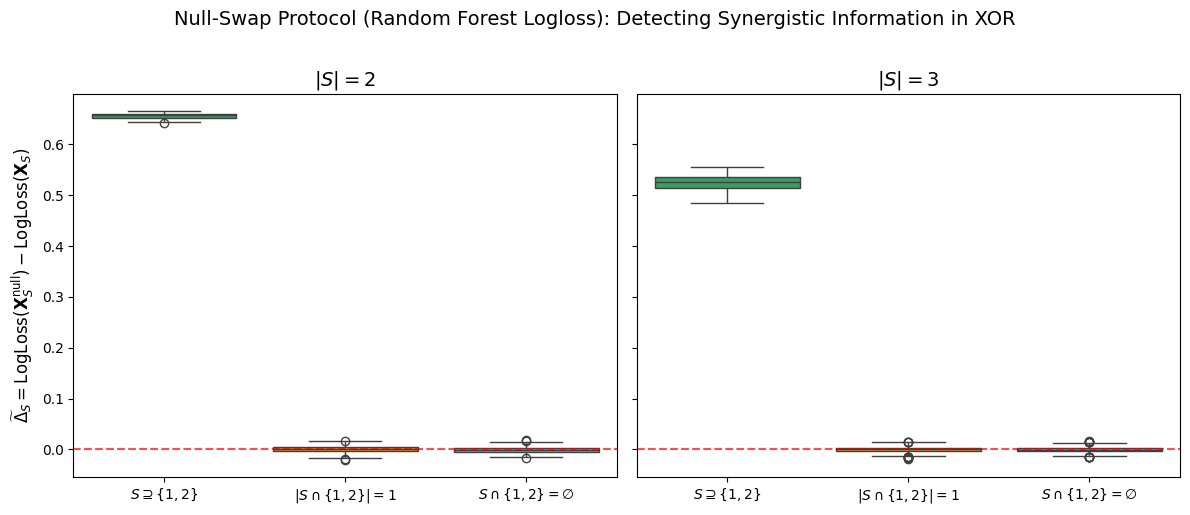

In [22]:
# Plot 1: Swap delta by combination type (paper notation)
# Only |S| = 2 and |S| = 3 on the SAME scale for comparison

category_order = [
    r"$S \supseteq \{1,2\}$",
    r"$|S \cap \{1,2\}| = 1$", 
    r"$S \cap \{1,2\} = \emptyset$"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, size in zip(axes, [2, 3]):
    data = results_df[results_df["combo_size"] == size]
    
    # Filter to categories that exist for this size
    existing_cats = [c for c in category_order if c in data["combo_type"].values]
    
    sns.boxplot(
        data=data,
        x="combo_type",
        y="delta",
        ax=ax,
        order=existing_cats,
        hue="combo_type",
        palette={"$S \\supseteq \\{1,2\\}$": "#27ae60", 
                 "$|S \\cap \\{1,2\\}| = 1$": "#f39c12",
                 "$S \\cap \\{1,2\\} = \\emptyset$": "#95a5a6"},
        legend=False
    )
    
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
    ax.set_title(rf"$|S| = {size}$", fontsize=14)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel(r"$\widetilde{\Delta}_S = \text{LogLoss}(\mathbf{X}_S^{\mathrm{null}}) - \text{LogLoss}(\mathbf{X}_S)$", fontsize=12)
axes[1].set_ylabel("")

plt.suptitle("Null-Swap Protocol (Random Forest Logloss): Detecting Synergistic Information in XOR", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


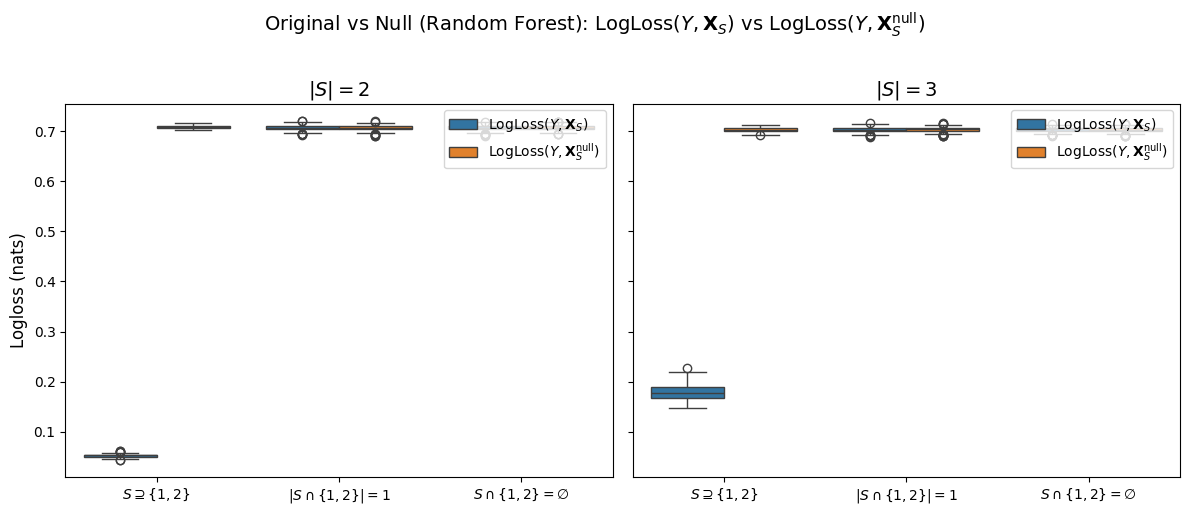

In [23]:
# Plot 2: Direct comparison LogLoss(Y, X_S) vs LogLoss(Y, X_S^null) - same scale for |S|=2,3
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, size in zip(axes, [2, 3]):
    data = results_df[results_df["combo_size"] == size]
    existing_cats = [c for c in category_order if c in data["combo_type"].values]
    
    # Melt for paired comparison
    data_melted = data.melt(
        id_vars=["combo", "combo_type", "realization"],
        value_vars=["logloss_original", "logloss_null"],
        var_name="version",
        value_name="LogLoss"
    )
    data_melted["version"] = data_melted["version"].map({
        "logloss_original": r"$\text{LogLoss}(Y, \mathbf{X}_S)$",
        "logloss_null": r"$\text{LogLoss}(Y, \mathbf{X}_S^{\mathrm{null}})$"
    })
    
    sns.boxplot(
        data=data_melted,
        x="combo_type",
        y="LogLoss",
        hue="version",
        ax=ax,
        order=existing_cats
    )
    
    ax.set_title(rf"$|S| = {size}$", fontsize=14)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="", loc="upper right")

axes[0].set_ylabel("Logloss (nats)", fontsize=12)
axes[1].set_ylabel("")

plt.suptitle(r"Original vs Null (Random Forest): $\text{LogLoss}(Y, \mathbf{X}_S)$ vs $\text{LogLoss}(Y, \mathbf{X}_S^{\mathrm{null}})$", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


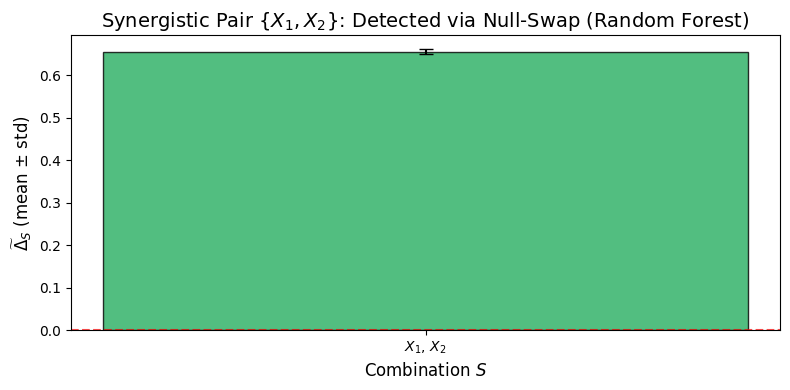

Mean Δ for synergistic pair: 0.655926 ± 0.005360


In [24]:
# Plot 3: Detailed view - Delta by specific combination (only synergistic pairs)
# Focus on |S|=2 combinations containing the synergistic pair {X_1, X_2}

synergistic_pairs = results_df[
    (results_df["combo_size"] == 2) & 
    (results_df["combo_type"] == r"$S \supseteq \{1,2\}$")
].copy()

# Summary by combo
pair_summary = synergistic_pairs.groupby("combo")["delta"].agg(["mean", "std", "count"]).reset_index()
pair_summary["combo_str"] = pair_summary["combo"].apply(lambda x: ", ".join(x))

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    pair_summary["combo_str"],
    pair_summary["mean"],
    yerr=pair_summary["std"],
    capsize=5,
    color="#27ae60",
    edgecolor="black",
    alpha=0.8
)

ax.axhline(y=0, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
ax.set_xlabel("Combination $S$", fontsize=12)
ax.set_ylabel(r"$\widetilde{\Delta}_S$ (mean ± std)", fontsize=12)
ax.set_title(r"Synergistic Pair $\{X_1, X_2\}$: Detected via Null-Swap (Random Forest)", fontsize=14)

plt.tight_layout()
plt.show()

print(f"Mean Δ for synergistic pair: {pair_summary['mean'].values[0]:.6f} ± {pair_summary['std'].values[0]:.6f}")


In [25]:
# Statistical test: Is Δ significantly different from 0?
# Only for |S| = 2 and |S| = 3
print("Statistical Test: H_0: E[Δ] = 0 vs H_1: E[Δ] ≠ 0")
print("="*75)
print(f"{'Category':<35} | |S| | Mean Δ    | p-value    | Sig.")
print("-"*75)

for combo_type in category_order:
    for size in [2, 3]:  # Only |S| = 2 and 3
        data = results_df[
            (results_df["combo_type"] == combo_type) & 
            (results_df["combo_size"] == size)
        ]["delta"]
        
        if len(data) == 0:
            continue
            
        t_stat, p_value = stats.ttest_1samp(data, 0)
        mean_delta = data.mean()
        
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        
        # Cleaner category names for printing
        cat_print = combo_type.replace("$", "").replace("\\", "").replace("{", "").replace("}", "")
        print(f"{cat_print:<35} | {size}   | {mean_delta:+.6f}   | {p_value:.2e} | {significance}")

print("-"*75)
print()
print("Interpretation:")
print("  - S ⊇ {1,2}: Significant positive Δ → Synergistic information DETECTED")
print("  - Other categories: Δ ≈ 0 → No information (as expected)")


Statistical Test: H_0: E[Δ] = 0 vs H_1: E[Δ] ≠ 0
Category                            | |S| | Mean Δ    | p-value    | Sig.
---------------------------------------------------------------------------
S supseteq 1,2                      | 2   | +0.655926   | 3.50e-104 | ***
S supseteq 1,2                      | 3   | +0.523930   | 0.00e+00 | ***
|S cap 1,2| = 1                     | 2   | +0.000157   | 5.46e-01 | ns
|S cap 1,2| = 1                     | 3   | +0.000168   | 2.23e-01 | ns
S cap 1,2 = emptyset                | 2   | -0.000222   | 2.89e-01 | ns
S cap 1,2 = emptyset                | 3   | -0.000201   | 2.17e-01 | ns
---------------------------------------------------------------------------

Interpretation:
  - S ⊇ {1,2}: Significant positive Δ → Synergistic information DETECTED
  - Other categories: Δ ≈ 0 → No information (as expected)


## Key Findings: Direct Logloss Swap Protocol

The null-swap protocol validates the epistemic framework using **Random Forest logloss directly** (without converting to mutual information).

### XOR Pattern (Contextual without Marginal Informativity)

Following paper notation, the swap delta is:
$$\widetilde{\Delta}_S = \text{LogLoss}(Y, \mathbf{X}_S^{\mathrm{null}}) - \text{LogLoss}(Y, \mathbf{X}_S)$$

**Interpretation:**
- $\widetilde{\Delta}_S > 0$ → Original logloss is lower → $X_S$ provides information about $Y$
- $\widetilde{\Delta}_S \approx 0$ → Original and null logloss are similar → $X_S$ provides no information

**Expected results by combination type (same scale for comparison):**

| Category | $|S|=2$ | $|S|=3$ |
|----------|---------|---------|
| $S \supseteq \{1,2\}$ (synergistic pair complete) | $\widetilde{\Delta} > 0$ *** | $\widetilde{\Delta} > 0$ *** |
| $|S \cap \{1,2\}| = 1$ (incomplete synergy) | $\widetilde{\Delta} \approx 0$ | $\widetilde{\Delta} \approx 0$ |
| $S \cap \{1,2\} = \emptyset$ (pure noise) | $\widetilde{\Delta} \approx 0$ | $\widetilde{\Delta} \approx 0$ |

### Interpretation in the Epistemic Framework

1. **Synergistic pair $\{X_1, X_2\}$**: Shows $\widetilde{\Delta} > 0$, confirming $\{X_1, X_2\} \in \mathcal{I}$ (joint information detected)

2. **Incomplete synergy**: Having only one of $X_1$ or $X_2$ is insufficient; $\widetilde{\Delta} \approx 0$ because the XOR signal requires **both** variables

3. **Pure noise**: $\widetilde{\Delta} \approx 0$ regardless of combination size, correctly identifying $Z_j \notin \mathcal{I}$

### Advantages of Direct Logloss:
- **Simpler interpretation**: No conversion from logloss to MI (avoids H(Y) estimation)
- **Direct predictive measure**: Logloss directly quantifies prediction quality
- **Robust to class imbalance**: Works naturally with imbalanced datasets
- **More interpretable for practitioners**: Logloss is a standard ML metric

### Conclusion

The null-swap protocol with **direct Random Forest logloss** successfully distinguishes:
- **True information** ($S \in \mathcal{I}$): Detected via $\widetilde{\Delta}_S > 0$
- **No information** ($S \notin \mathcal{I}$): Confirmed via $\widetilde{\Delta}_S \approx 0$

This validates the protocol's utility using a direct predictive metric for identifying membership in the informative space $\mathcal{I}$, especially for synergistic (non-marginal) information structures like XOR.


In [26]:
# Save results for further analysis
results_df.to_csv("swap_protocol_rf_results.csv", index=False)
print("Results saved to swap_protocol_rf_results.csv")


Results saved to swap_protocol_rf_results.csv
